<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📚 Importing Libraries
</h2>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, preprocessing, linear_model
import warnings
warnings.filterwarnings("ignore")

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🔄 Load the <code>.npy</code> File and Use a Boolean Value to Determine Whether to Perform Classification or Regression
</h2>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
x_train = np.load('/content/drive/MyDrive/Time Series Data/Blink/x_train.npy')
y_train = np.load('/content/drive/MyDrive/Time Series Data/Blink/y_train.npy')
x_test  = np.load('/content/drive/MyDrive/Time Series Data/Blink/x_test.npy')
y_test  = np.load('/content/drive/MyDrive/Time Series Data/Blink/y_test.npy')
is_classification = len(np.unique(y_train)) / len(y_train) < 0.05

print(is_classification)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📊 Displaying Samples, Classes, Labels, Mean, and Variance
</h2>

In [ ]:
if is_classification:
    print("x_train:",x_train.shape);
    print("x_test:",x_test.shape);
    Train_classes, Train_counts = np.unique(y_train, return_counts=True)
    Test_classes, Test_counts = np.unique(y_test, return_counts=True)
    print("Train_Classes:", Train_classes)
    print("Train_Counts:", Train_counts)

else:
    print(x_train.shape);
    print(x_test.shape);
    print("Target mean:", np.mean(y_train))
    print("Target var:", np.var(y_train))

x_train: (500, 20000)
x_test: (450, 20000)
Train_Classes: ['longblink' 'shortblink']
Train_Counts: [250 250]


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📈 Displaying the Class Distribution Graph for the Classification Data
</h2>

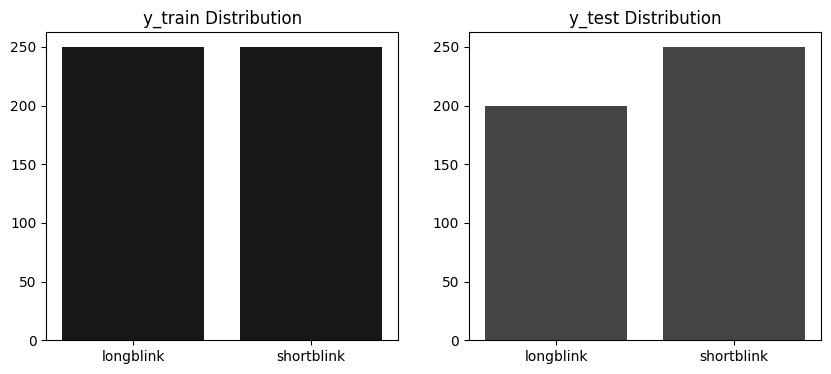

In [ ]:
if is_classification:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.bar(Train_classes.astype(str), Train_counts, color='#181818')
    plt.title('y_train Distribution')

    plt.subplot(1, 2, 2)
    plt.bar(Test_classes.astype(str), Test_counts, color='#444444')
    plt.title('y_test Distribution')

    plt.show()

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🏷️ Generating Numerical Class Labels for Classification
</h2>

In [ ]:
if is_classification:
    print(y_train[:10])
    from sklearn.preprocessing import LabelEncoder

    if not np.issubdtype(y_train.dtype, np.number):
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)
        print("Labels were non-numeric. Encoded classes:", le.classes_)
    else:
        print("Labels are already numeric. No encoding needed.")

    print(y_train[:10])

['longblink' 'longblink' 'longblink' 'longblink' 'longblink' 'longblink'
 'longblink' 'longblink' 'longblink' 'longblink']
Labels were non-numeric. Encoded classes: ['longblink' 'shortblink']
[0 0 0 0 0 0 0 0 0 0]


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  ⚖️ Applying Feature Scaling to Normalize the Dataset
</h2>

In [ ]:
x_norm = preprocessing.minmax_scale(x_train)
x_train = x_norm
x_norm = preprocessing.minmax_scale(x_test)
x_test = x_norm

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🧮 Implementing Ridge Regression and Ridge Classifier
</h2>

In [ ]:
if is_classification:
    clf = linear_model.RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
    clf.fit(x_train, y_train)
    print("Best alpha:", clf.alpha_)
    print("Train Accuracy: {:.2f}%".format(clf.score(x_train, y_train) * 100))
    print("Test Accuracy: {:.2f}%".format(clf.score(x_test, y_test) * 100))
else:
    from sklearn.metrics import mean_squared_error

    reg = linear_model.RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
    reg.fit(x_train, y_train)
    print("Best alpha:", reg.alpha_)

    y_train_pred = reg.predict(x_train)
    y_test_pred = reg.predict(x_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_nrmse = train_rmse / np.std(y_train)
    test_nrmse = test_rmse / np.std(y_test)

    print("Train NRMSE: {:.4f}".format(train_nrmse))
    print("Test NRMSE: {:.4f}".format(test_nrmse))

Best alpha: 10.0
Train Accuracy: 100.00%
Test Accuracy: 67.56%


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🔄 Fetching Data Again for Standardization
</h2>

In [ ]:
x_train = np.load('/content/drive/MyDrive/Time Series Data/Blink/x_train.npy')
y_train = np.load('/content/drive/MyDrive/Time Series Data/Blink/y_train.npy')
x_test  = np.load('/content/drive/MyDrive/Time Series Data/Blink/x_test.npy')
y_test  = np.load('/content/drive/MyDrive/Time Series Data/Blink/y_test.npy')

is_binary = len(np.unique(y_train)) == 2
if is_classification:
    print(y_train[:10])
    from sklearn.preprocessing import LabelEncoder

    if not np.issubdtype(y_train.dtype, np.number):
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')

mean = x_train.mean(axis=0)
std  = x_train.std(axis=0) + 1e-8

x_train_norm = (x_train - mean) / std
x_test_norm  = (x_test  - mean) / std

['longblink' 'longblink' 'longblink' 'longblink' 'longblink' 'longblink'
 'longblink' 'longblink' 'longblink' 'longblink']


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">🧠 Neural Network</h2>

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

x_train, y_train = torch.tensor(x_train_norm, device=device), torch.tensor(y_train, device=device)
x_test,  y_test  = torch.tensor(x_test_norm,  device=device), torch.tensor(y_test,  device=device)


<h1 align="center">🧠 Classification vs Regression</h1>


In [ ]:
if is_classification:

    class Classifier(nn.Module):
        def __init__(self, input_dim=8, output_dim=1, dropout=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, output_dim)
            )

        def forward(self, x):
            return self.net(x)


    if is_binary:
        y_train = ((y_train + 1) // 2).float()
        y_test  = ((y_test  + 1) // 2).float()
        output_dim = 1
        loss_fn = nn.BCEWithLogitsLoss()
        loss_name = "BCE"
    else:
        y_train = y_train.long()
        y_test  = y_test.long()
        output_dim = int(y_train.max().item()) + 1
        loss_fn = nn.CrossEntropyLoss()
        loss_name = "CE"

    torch.manual_seed(430)

    classifier = Classifier(x_train.shape[-1], output_dim).to(device)
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

    best_loss = float('inf')
    best_state = None
    patience_counter = 0
    PATIENCE = 100

    epochs = 1000
    for epoch in range(epochs):
        classifier.train()
        if is_binary:
            logits = classifier(x_train).squeeze(-1)
        else:
            logits = classifier(x_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        if loss.item() < best_loss - 1e-4:
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in classifier.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stop at epoch {epoch+1}")
                break

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Train {loss_name}: {loss.item():.4f}")

    if best_state is not None:
        classifier.load_state_dict(best_state)

    classifier.eval()
    with torch.no_grad():
        if is_binary:
            logits = classifier(x_test).squeeze(-1)
            test_loss = loss_fn(logits, y_test)
            preds = (torch.sigmoid(logits) > 0.5).float()
        else:
            logits = classifier(x_test)
            test_loss = loss_fn(logits, y_test)
            preds = logits.argmax(dim=-1)
        acc = (preds == y_test).float().mean()

    print(f"\nTest {loss_name}       : {test_loss.item():.4f}")
    print(f"Test Accuracy: {acc.item() * 100:.2f}%")
else:

    class Regressor(nn.Module):
        def __init__(self, input_dim=8, output_dim=1):
            super().__init__()
            self.layer1 = nn.Linear(input_dim, 64)
            self.layer2 = nn.Linear(64, 32)
            self.layer3 = nn.Linear(32, output_dim)

        def forward(self, x):
            x = torch.tanh(self.layer1(x))
            x = torch.tanh(self.layer2(x))
            x = self.layer3(x)
            return x

    loss_fn = nn.MSELoss()

    torch.manual_seed(430)

    regressor = Regressor(x_train.shape[-1]).to(device)
    optimizer = torch.optim.AdamW(regressor.parameters(), lr=0.001)

    epochs = 1000
    for epoch in range(epochs):
        regressor.train()
        preds = regressor(x_train).squeeze(-1)
        loss = loss_fn(preds, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Train MSE: {loss.item():.4f}")


    regressor.eval()
    with torch.no_grad():
        preds = regressor(x_test).squeeze(-1)
        mse   = loss_fn(preds, y_test)
        rmse  = torch.sqrt(mse)
        nrmse = rmse / (y_test.max() - y_test.min())
        ss_res = ((y_test - preds) ** 2).sum()
        ss_tot = ((y_test - y_test.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot

    print(f"\nTest NRMSE   : {nrmse.item():.4f}")
    print(f"Test R²      : {r2.item():.4f}")

Epoch 100 | Train BCE: 0.0779
Epoch 200 | Train BCE: 0.0269
Epoch 300 | Train BCE: 0.0126
Epoch 400 | Train BCE: 0.0083
Epoch 500 | Train BCE: 0.0058
Epoch 600 | Train BCE: 0.0039
Epoch 700 | Train BCE: 0.0039
Epoch 800 | Train BCE: 0.0023
Epoch 900 | Train BCE: 0.0021
Epoch 1000 | Train BCE: 0.0019

Test BCE       : 1.5071
Test Accuracy: 70.44%
